# Street-Giving Lambda: Final Write-Up

This notebook documents the final empirical model and its outputs. The aim is to estimate a relative hourly surface of street-giving opportunity across central London, not to predict exact income for any individual. The model combines observed movement, local economic geography, behavioural giving probabilities, and borough-level competition pressure.


In [1]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (8, 4.6),
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

root = os.getcwd()
processed = os.path.join(root, "data", "processed")
out = os.path.join(root, "outputs", "analysis")

areas = gpd.read_file(os.path.join(processed, "areas_lsoa.gpkg"))
footfall = pd.read_csv(os.path.join(processed, "station_footfall.csv"))
coords = pd.read_csv(os.path.join(processed, "station_coords.csv"))
rods = pd.read_csv(os.path.join(processed, "rods_profiles.csv"))
bres = pd.read_csv(os.path.join(processed, "bres_section_lsoa.csv"), dtype={"msoa": str})
ashe = pd.read_csv(os.path.join(processed, "ashe_section_pay.csv"))
pois = gpd.read_file(os.path.join(processed, "osm_pois.geojson"))
rough = pd.read_csv(os.path.join(processed, "rough_sleeping_borough.csv"))
hourly = pd.read_csv(os.path.join(out, "hourly_lambda.csv"))
surface = gpd.read_file(os.path.join(out, "lambda_surface.gpkg"))

hours = np.arange(24)
segments = ["workers", "leisure", "shoppers", "tourists", "events", "students"]

def cite(fig, text):
    fig.text(0.01, 0.01, text, ha="left", va="bottom", fontsize=8, color="#555555")
    fig.subplots_adjust(bottom=0.18)


## 1. Spatial Unit of Analysis

The analysis uses [ONS Open Geography Portal boundaries](https://geoportal.statistics.gov.uk/) to divide central London into 2,130 Lower Super Output Areas (LSOAs). Each LSOA is treated as one small spatial unit. For every LSOA $\ell$ and hour $t$, the model calculates $\lambda(\ell,t)$, a relative measure of hourly giving opportunity.

This spatial unit is useful because it is fine enough to show variation within boroughs, but still stable enough to connect to employment, rough-sleeping and point-of-interest data. The model should therefore be interpreted as an area-level surface rather than a prediction about any one street corner.


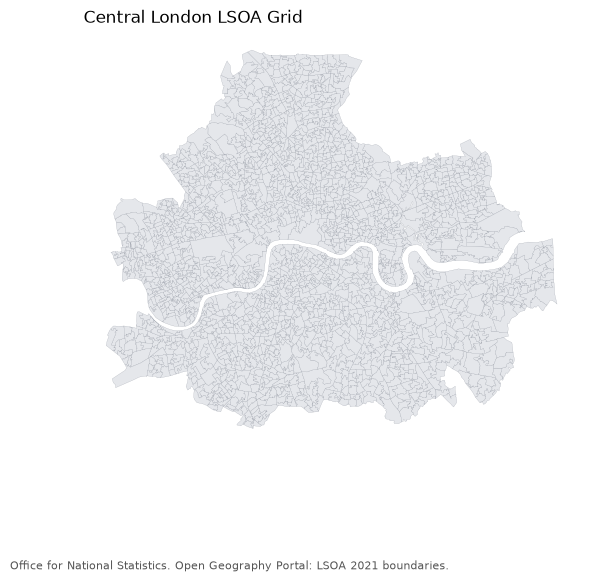

In [2]:
fig, ax = plt.subplots(figsize=(6.4, 6.4))
areas.plot(ax=ax, facecolor="#e5e7eb", edgecolor="#6b7280", linewidth=0.10)
ax.set_title("Central London LSOA Grid", loc="left")
ax.set_axis_off()
cite(fig, "Office for National Statistics. Open Geography Portal: LSOA 2021 boundaries.")
plt.show()


## 2. Footfall: Measuring Opportunity

Footfall is the opportunity term in the model. I use [TfL station usage data](https://crowding.data.tfl.gov.uk) for daily station volumes, the [TfL Rolling Origin and Destination Survey](https://data.london.gov.uk/dataset/tfl-rolling-origin-and-destination-survey-2w97n/) for the hourly distribution of station movement, and the [TfL StopPoint API](https://api.tfl.gov.uk) for station coordinates. These sources are combined to estimate how much movement is available near each LSOA in each hour.

The chart below shows the central London station-flow profile implied by the TfL and RODS inputs. Weekdays show stronger commuting structure, while weekends have a different and generally flatter shape. This hourly transport pattern is the main source of time variation in the model.


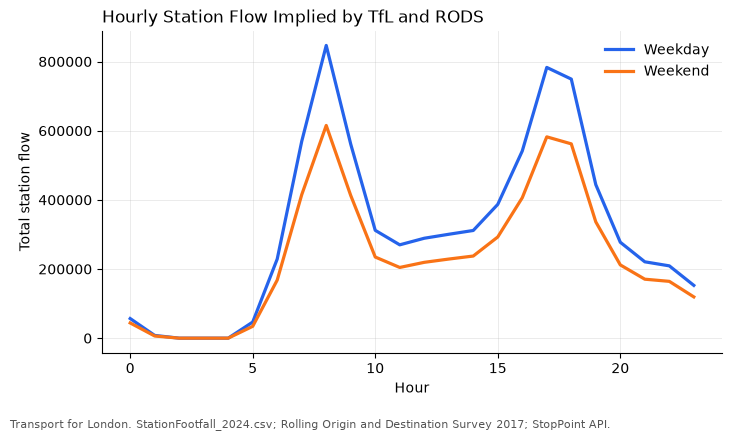

In [3]:
stations = footfall.merge(coords, on="norm").merge(rods, on="norm", how="left")
profile_cols = [f"h{h}" for h in hours]
stations[profile_cols] = stations[profile_cols].fillna(rods[profile_cols].mean())
curves = {}
for daytype in ["weekday", "weekend"]:
    curves[daytype] = (stations[daytype].fillna(0).values[:, None] * stations[profile_cols].values).sum(axis=0)

fig, ax = plt.subplots()
ax.plot(hours, curves["weekday"], lw=2.3, label="Weekday", color="#2563eb")
ax.plot(hours, curves["weekend"], lw=2.3, label="Weekend", color="#f97316")
ax.set_title("Hourly Station Flow Implied by TfL and RODS", loc="left")
ax.set_xlabel("Hour")
ax.set_ylabel("Total station flow")
ax.legend(frameon=False)
cite(fig, "Transport for London. StationFootfall_2024.csv; Rolling Origin and Destination Survey 2017; StopPoint API.")
plt.show()


## 3. Segment Geography and Giving Capacity

The model separates six broad crowd segments: workers, leisure, shoppers, tourists, events and students. Workers are indexed from [BRES employment on Nomis](https://www.nomisweb.co.uk/datasets/newbres6pub), weighted by industry pay from [ONS ASHE](https://www.ons.gov.uk/employmentandlabourmarket/peopleinwork/earningsandworkinghours/datasets/regionbyindustry2digitsicashetable5). This gives a worker index that reflects both where jobs are concentrated and the relative income mix of those jobs.

For the other five segments, the model uses [OpenStreetMap points of interest from Geofabrik](https://download.geofabrik.de/europe/united-kingdom/england/greater-london.html). Restaurants, pubs and bars proxy leisure; shops proxy shoppers; hotels and attractions proxy tourists; theatres, cinemas and venues proxy events; universities, colleges and schools proxy students. These indices are used both to estimate segment mix and to approximate regional spending capacity.


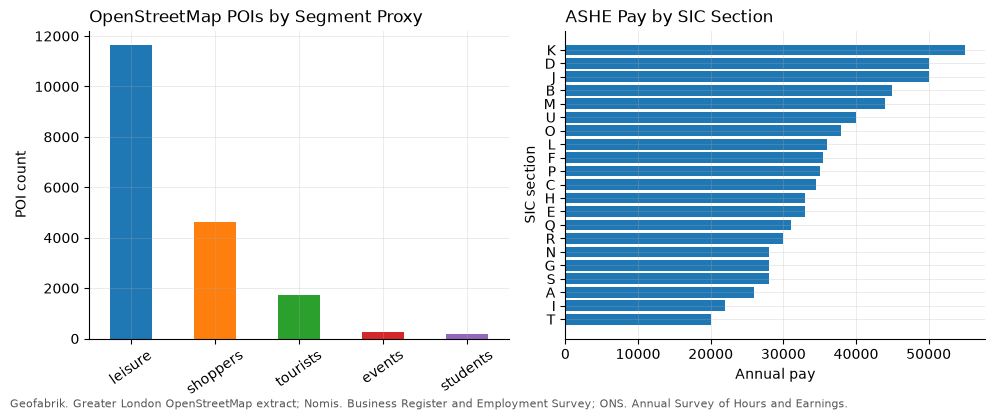

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
poi_counts = pois["poi_group"].value_counts().reindex(["leisure", "shoppers", "tourists", "events", "students"])
poi_counts.plot(kind="bar", ax=axes[0], color=plt.cm.tab10.colors[:5])
axes[0].set_title("OpenStreetMap POIs by Segment Proxy", loc="left")
axes[0].set_xlabel("")
axes[0].set_ylabel("POI count")
axes[0].tick_params(axis="x", rotation=35)

pay = ashe.sort_values("annual_pay")
axes[1].barh(pay["section"], pay["annual_pay"], color="#1f77b4")
axes[1].set_title("ASHE Pay by SIC Section", loc="left")
axes[1].set_xlabel("Annual pay")
axes[1].set_ylabel("SIC section")
plt.tight_layout()
cite(fig, "Geofabrik. Greater London OpenStreetMap extract; Nomis. Business Register and Employment Survey; ONS. Annual Survey of Hours and Earnings.")
plt.show()


## 4. Probability of Giving

The only behavioural inputs set directly are the segment-level giving probabilities $p_d$. These values are not fitted to match the map. They encode a simple ordering from the literature: students are highest, leisure and event-goers are also relatively high, tourists are intermediate, and shoppers and rushed workers are lower. This ordering is informed by the [ASU Center for Problem-Oriented Policing guide to panhandling](https://popcenter.asu.edu/content/panhandling-0) and [Sharma and Malik (2025)](https://www.prf.cuni.cz/sites/default/files/uploads/files/Sharma-JMP2025.pdf).

This is the main behavioural assumption in the model. The spatial variation comes from the data, but the relative likelihood that each segment gives is imposed from external evidence.


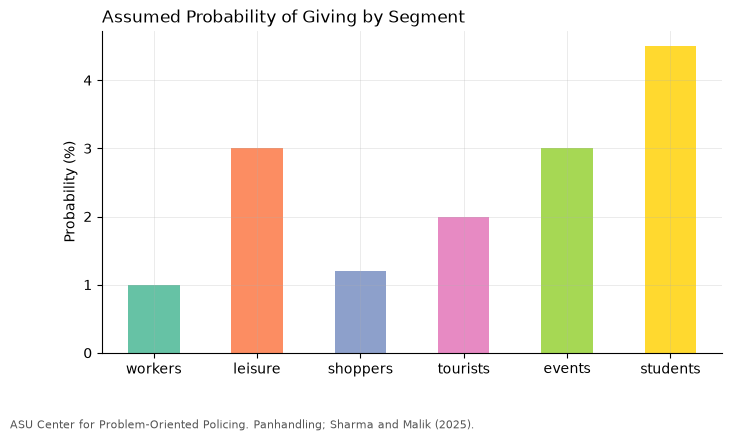

In [5]:
p_give = pd.Series({"workers": 0.010, "leisure": 0.030, "shoppers": 0.012, "tourists": 0.020, "events": 0.030, "students": 0.045})
fig, ax = plt.subplots()
(p_give * 100).plot(kind="bar", ax=ax, color=plt.cm.Set2.colors[:6])
ax.set_title("Assumed Probability of Giving by Segment", loc="left")
ax.set_xlabel("")
ax.set_ylabel("Probability (%)")
ax.tick_params(axis="x", rotation=0)
cite(fig, "ASU Center for Problem-Oriented Policing. Panhandling; Sharma and Malik (2025).")
plt.show()


## 5. Gross Giving Pool

For each LSOA-hour, gross giving is computed as

$$
\mathrm{gross}(\ell,t)=\sum_d a_d(\ell)\,p_d\,f_d(\ell,t).
$$

Here $f_d(\ell,t)$ is segment footfall, $p_d$ is the probability of giving, and $a_d(\ell)$ is a regional spend index. Gross giving is therefore the modelled giving pool before competition is applied. The map below shows the weekday midday gross surface, which is high in dense, connected and commercially active parts of central London.


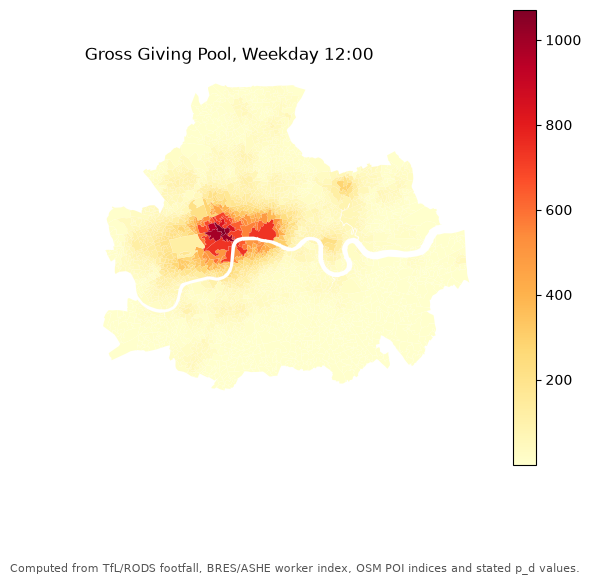

In [6]:
plot_g = surface.to_crs("EPSG:27700")
fig, ax = plt.subplots(figsize=(6.5, 6.5))
plot_g.plot(ax=ax, column="weekday_gross_h12", cmap="YlOrRd", linewidth=0.03, edgecolor="white", legend=True)
ax.set_title("Gross Giving Pool, Weekday 12:00", loc="left")
ax.set_axis_off()
cite(fig, "Computed from TfL/RODS footfall, BRES/ASHE worker index, OSM POI indices and stated p_d values.")
plt.show()


## 6. Competition

Competition is measured at borough level using the [MHCLG rough-sleeping snapshot](https://www.gov.uk/government/statistics/rough-sleeping-snapshot-in-england-autumn-2023). The competition pressure term compares rough-sleeper counts with the borough's gross giving pool. A borough with many rough sleepers relative to available giving is discounted more heavily.

Because this uses rough-sleeping counts as an input, those same counts cannot be used as an independent validation target in this version. The competition term should therefore be read as a coarse adjustment for dilution, not as a fine-grained measure of who is present on each street.


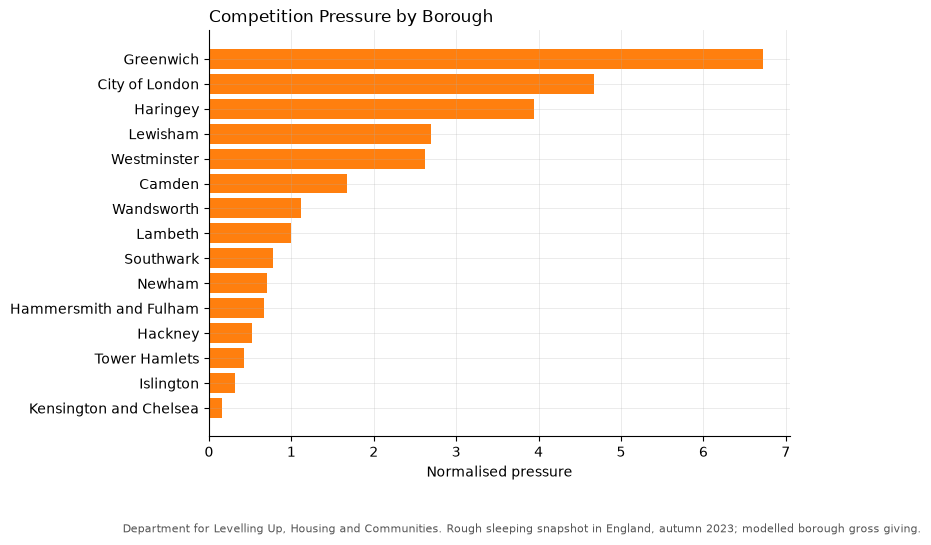

In [7]:
comp = surface[["borough", "competition_pressure"]].drop_duplicates().sort_values("competition_pressure")
fig, ax = plt.subplots(figsize=(7.5, 5.8))
ax.barh(comp["borough"], comp["competition_pressure"], color="#ff7f0e")
ax.set_title("Competition Pressure by Borough", loc="left")
ax.set_xlabel("Normalised pressure")
ax.set_ylabel("")
cite(fig, "Department for Levelling Up, Housing and Communities. Rough sleeping snapshot in England, autumn 2023; modelled borough gross giving.")
plt.show()


## 7. Final Lambda Surface

The final value is gross giving after competition:

$$
\lambda(\ell,t)=\mathrm{gross}(\ell,t)-c(\ell,t).
$$

In implementation, the competition cost is bounded as a share of gross giving, so $\lambda$ remains non-negative. The hourly series below shows the total modelled lambda across central London by hour. It is strongest when transport flow and high-opportunity places coincide.


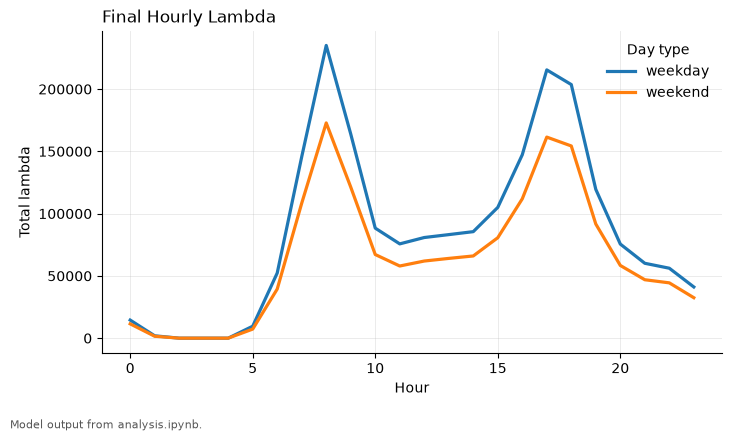

In [8]:
fig, ax = plt.subplots()
hourly.groupby(["hour", "daytype"])["lambda"].sum().unstack().plot(ax=ax, lw=2.3)
ax.set_title("Final Hourly Lambda", loc="left")
ax.set_xlabel("Hour")
ax.set_ylabel("Total lambda")
ax.legend(frameon=False, title="Day type")
cite(fig, "Model output from analysis.ipynb.")
plt.show()


## 8. Time-of-Day Maps

Aggregating the hourly results into broad time periods makes the geography easier to interpret. These period maps are not separate models. They are summaries of the same hourly $\lambda(\ell,t)$ surface.


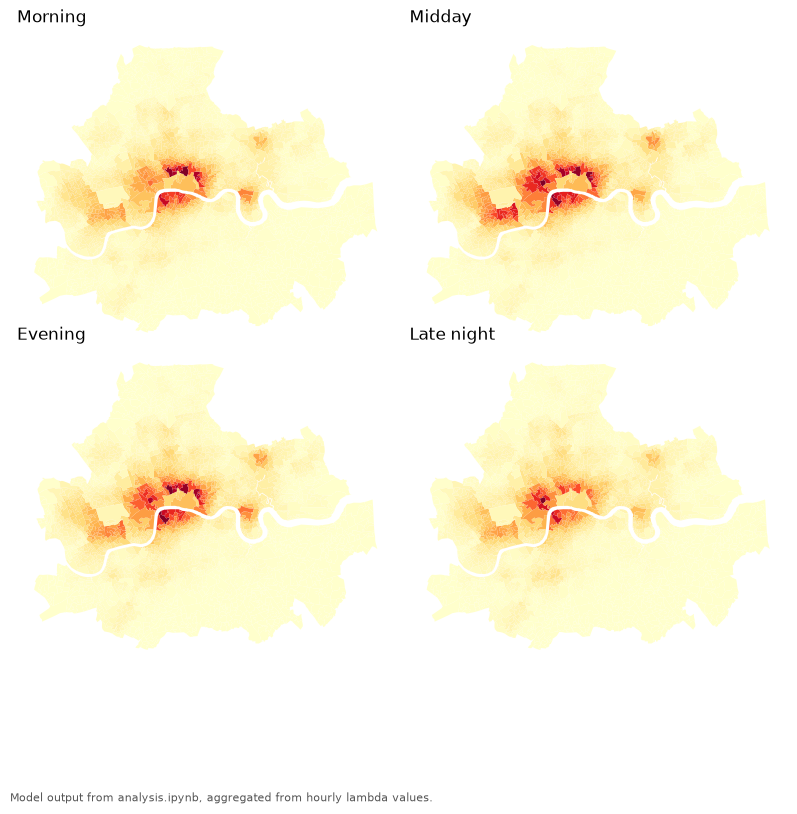

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
periods = ["weekday_morning", "weekday_midday", "weekday_evening", "weekday_late_night"]
titles = ["Morning", "Midday", "Evening", "Late night"]
for ax, col, title in zip(axes.ravel(), periods, titles):
    plot_g.plot(ax=ax, column=col, cmap="YlOrRd", linewidth=0.02, edgecolor="white")
    ax.set_title(title, loc="left")
    ax.set_axis_off()
plt.tight_layout()
cite(fig, "Model output from analysis.ipynb, aggregated from hourly lambda values.")
plt.show()


## 9. Interpretation of Results

The model should be interpreted as a relative surface of giving opportunity, not as a literal estimate of personal income. High values mean that, according to the input datasets, an area combines substantial passing flow, a favourable crowd mix and relatively lower competition pressure. Low values mean that at least one of these conditions is weak.

The hourly curve suggests that transport-driven movement is central to the surface. Weekday opportunity rises around commuter periods, while weekend opportunity is flatter and more leisure-oriented. This does not mean that all giving happens at stations; it means that station-linked movement is the strongest observed proxy available in this version of the model.

Spatially, the model tends to favour dense, active and connected places: areas around major stations, commercial districts, entertainment clusters, retail streets and cultural or tourist destinations. The surface is best read as exposure to potentially giving pedestrians after adjusting for competition. It is not a map of need, deprivation, policing, shelter access or actual rough-sleeping presence.

The competition term changes the interpretation. Before competition, the model asks where the gross giving pool is largest. After competition, it asks where that pool may be less diluted by the number of people also relying on it. Because competition is measured only at borough level, this part of the model is deliberately coarse. It can shift values between boroughs but cannot distinguish two nearby LSOAs inside the same borough by local competition.

The most important limitation is that several concepts are proxied rather than directly observed. OSM venue density stands in for both crowd composition and spending capacity; BRES/ASHE stands in for worker income; TfL and RODS stand in for pedestrian movement; MHCLG counts stand in for competition. These are reasonable first-order proxies, but they should not be overread. A stronger future version would separate crowd presence from spend, use segment-specific hourly profiles, and use finer-grained outreach or CHAIN-style competition data if available.


In [10]:
summary = pd.DataFrame({
    "Reading": [
        "High lambda",
        "Low lambda",
        "Strong gross but lower final lambda",
        "Strong period-specific lambda",
    ],
    "Interpretation": [
        "High flow, favourable crowd mix and lower competition pressure.",
        "Weak flow, lower-spend crowd mix or stronger competition pressure.",
        "The area has giving opportunity, but competition reduces the final value.",
        "The area is more attractive during a particular part of the day.",
    ],
})
summary


,Reading,Interpretation
0,High lambda,"High flow, favourable crowd mix and lower comp..."
1,Low lambda,"Weak flow, lower-spend crowd mix or stronger c..."
2,Strong gross but lower final lambda,"The area has giving opportunity, but competiti..."
3,Strong period-specific lambda,The area is more attractive during a particula...


## 10. Best Place by Hour

Finally, I trace the single highest-$\lambda$ LSOA for each hour. This is not a practical instruction or recommendation. It is simply the maximum point of the modelled surface at each hour. It answers: if the model is taken literally, where is the hourly opportunity score highest?


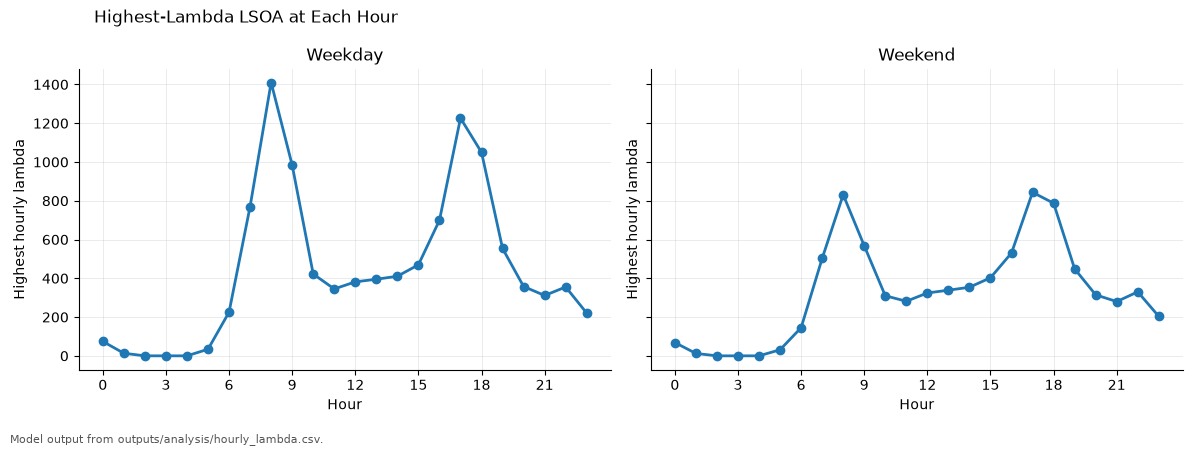

,daytype,hour,msoa_name,borough,lambda
1848,weekday,0,Camden 028D,Camden,74.3
1849,weekday,1,Camden 028D,Camden,13.3
2,weekday,2,City of London 001A,City of London,0.0
3,weekday,3,City of London 001A,City of London,0.0
4,weekday,4,City of London 001A,City of London,0.0
47717,weekday,5,Newham 012F,Newham,34.0
15150,weekday,6,Islington 023D,Islington,225.2
15151,weekday,7,Islington 023D,Islington,770.2
15152,weekday,8,Islington 023D,Islington,1410.0
15609,weekday,9,Islington 022D,Islington,983.9


In [11]:
best = hourly.loc[hourly.groupby(["daytype", "hour"])["lambda"].idxmax()].copy()
best = best.sort_values(["daytype", "hour"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, daytype in zip(axes, ["weekday", "weekend"]):
    sub = best[best["daytype"] == daytype]
    ax.plot(sub["hour"], sub["lambda"], marker="o", lw=2)
    ax.set_title(daytype.title())
    ax.set_xlabel("Hour")
    ax.set_ylabel("Highest hourly lambda")
    ax.set_xticks(range(0, 24, 3))
plt.suptitle("Highest-Lambda LSOA at Each Hour", x=0.08, ha="left", fontsize=12)
plt.tight_layout()
cite(fig, "Model output from outputs/analysis/hourly_lambda.csv.")
plt.show()

best_table = best[["daytype", "hour", "msoa_name", "borough", "lambda"]].copy()
best_table["lambda"] = best_table["lambda"].round(1)
best_table
